In [19]:
import matplotlib.pyplot as plt
import pandas as pd

from testrig_control_with_sofirpy.experimental_run import ExperimentalRun

# from sofirpy import plot_results
import test_rig_control_model.common as co
from testrig_control_with_sofirpy.utils import get_run_names_from_file

import scipy.stats as st
import numpy as np

plt.style.use("../FST.mplstyle")
plt.rcParams["font.size"] = 13
plt.rcParams.update({"text.usetex": True, "font.family": "Helvetica"})

import requests
import re


# Visualisation of experimental and simulation results
This notebook plots simulation data obtained with the corresponding jupyter notebooks in this directory.

The diagrams were presented at the WDSA/CCWI 2026 in the talk *Applying the Elastic Water Column Model with Dynamic Elements to a Physical Test Rig* by Kevin Logan, Michaela Lestakova, Peter F. Pelz.

The data is downloaded from the institutional repository of TU Darmstadt, TUDatalib https://tudatalib.ulb.tu-darmstadt.de/items/ad4f7f36-0777-45b0-b523-095320182b72, which contains supplementary material for the contribution.

In [ ]:
def download_hdf5_files(urls, location="../data/"):
    for url in urls:
        r = requests.get(url)
        r.raise_for_status()
        cd = r.headers.get("Content-Disposition")
        if cd:
            m = re.search(r'filename="?([^"]+)"?', cd)
            if m:
                filename = m.group(1)
            else:
                print("URL {} could not be read".format(url))
                continue
        else:
            print("URL {} could not be read".format(url))
            continue

        with open(location + filename, "wb") as f:
            f.write(r.content)

## Load simulation results

The next cell downloads and loads the experimental results from the TUDatalib repository https://tudatalib.ulb.tu-darmstadt.de/items/ad4f7f36-0777-45b0-b523-095320182b72

In [23]:
sim_df_c_35_75_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/bd636e6b-16c8-4d2d-b866-8328a7836732/download"
sim_df_c_35_50_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/8946b2c4-71c0-4347-bd7b-29c745d832a8/download"
sim_df_c_41_75_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/c959aa94-3e03-44da-986e-f673cdb5f7c2/download"
sim_df_p_35_41_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/97c0afbd-45ea-4504-9fa2-fe2d7266e7d1/download"
sim_df_v_25s_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/ac0304f7-cde8-4129-974f-2543a2da4bc5/download"
sim_df_v_5s_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/c3424a3f-96f9-4b34-ad51-62012de7c951/download"

download_hdf5_files(
    [
        sim_df_c_35_75_url,
        sim_df_c_35_50_url,
        sim_df_c_41_75_url,
        sim_df_p_35_41_url,
        sim_df_v_25s_url,
        sim_df_v_5s_url,
    ]
)

sim_df_c_35_75 = pd.read_hdf(
    "../data/simulation_constant_operating_point_3536_75.hdf5", "df"
)
sim_df_c_35_50 = pd.read_hdf(
    "../data/simulation_constant_operating_point_3536_50.hdf5", "df"
)
sim_df_c_41_75 = pd.read_hdf(
    "../data/simulation_constant_operating_point_4167_75.hdf5", "df"
)
sim_df_p_35_41 = pd.read_hdf("../data/simulation_pump_speedup_3536_to_41.hdf5", "df")
sim_df_v_25s = pd.read_hdf("../data/simulation_valve_closure_3536_75_to_50.hdf5", "df")
sim_df_v_5s = pd.read_hdf(
    "../data/simulation_valve_closure_3536_75_to_50_5s.hdf5", "df"
)

Alternatively, inspect the files created by running the jupyter notebooks after uncommenting:

In [ ]:
# sim_df_c_35_75 = pd.read_hdf("../data/constant_operating_point_3536_75.hdf5", "df")
# sim_df_c_35_50 = pd.read_hdf("../data/constant_operating_point_3536_50.hdf5", "df")
# sim_df_c_41_75 = pd.read_hdf("../data/constant_operating_point_4167_75.hdf5", "df")
# sim_df_p_35_41 = pd.read_hdf("../data/pump_speedup_3536_to_41.hdf5", "df")
# sim_df_v_25s = pd.read_hdf("../data/valve_closure_3536_75_to_50.hdf5", "df")
# sim_df_v_5s = pd.read_hdf("../data/valve_closure_3536_75_to_50_5s.hdf5", "df")

## Load experimental results

The next cell downloads and loads the experimental results from the TUDatalib repository https://tudatalib.ulb.tu-darmstadt.de/items/ad4f7f36-0777-45b0-b523-095320182b72

In [25]:
exp_df_c_35_75_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/3a1a73d6-d795-425e-b9b0-bd8f49993108/download"
exp_df_c_35_50_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/10f722f5-1dad-44b9-9e74-12caf24230b0/download"
exp_df_c_41_75_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/38fb176d-51c0-44a1-9c95-ad3b943e7148/download"
exp_df_p_35_41_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/e6c132bb-293a-425e-9251-e98054c13624/download"
exp_df_v_25s_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/6daf5377-c219-41ae-9495-de167ef5ccd1/download"
exp_df_v_5s_url = "https://tudatalib.ulb.tu-darmstadt.de/bitstreams/65feadbe-c4fc-4cdb-b424-958dd5de47ac/download"

download_hdf5_files(
    [
        exp_df_c_35_75_url,
        exp_df_c_35_50_url,
        exp_df_c_41_75_url,
        exp_df_p_35_41_url,
        exp_df_v_25s_url,
        exp_df_v_5s_url,
    ]
)


def get_exp_results(file_name, run_index, location="../data/"):
    run_names = get_run_names_from_file(location + file_name)
    usable_runs = run_names
    run = ExperimentalRun.from_hdf5(usable_runs[run_index], location + file_name)
    return run.time_series


exp_df_c_35_75 = get_exp_results("system_1_constant_operating_point_3536_75.hdf5", 1)
exp_df_c_35_50 = get_exp_results(
    "subsystem_1_step_response_operating_point_2kPa.hdf5", 11
)
exp_df_c_41_75 = get_exp_results("system_1_constant_operating_point_4167_75.hdf5", 0)
exp_df_p_35_41 = get_exp_results("system_1_pump_speed_up_3536_to_4167.hdf5", 1)
exp_df_v_25s = get_exp_results("system_1_valve_closure_75_to_50_25s.hdf5", 0)
exp_df_v_5s = get_exp_results("system_1_valve_closure_75_to_50_5s.hdf5", 0)

HDF5ToRun::WARNING::The following dependencies were installed when storing the run in the hdf5 and are not installed in the current environment:
mypy-extensions, future
HDF5ToRun::WARNING::The following dependencies have a different version: tzlocal, scipy, OMPython, Jinja2, uncertainties, tzdata, charset-normalizer, pytz, iniconfig, types-tqdm, ruff, certifi, kiwisolver, packaging, platformdirs, attrs, idna, MarkupSafe, mypy, FMPy, filelock, pillow, pre_commit, fonttools, pip, numpy, lark, numexpr, pluggy, pandas, hightime, click, six, tables, types-pytz, PyYAML, typing_extensions, matplotlib, pyzmq, joblib, distlib, pytest-cov, identify, psutil, virtualenv, cloudpickle, statsmodels, msgpack, pytest, lxml, contourpy, pywin32, python-gitlab, scikit-learn, ruptures, urllib3, ndindex, h5py, pandas-stubs, coverage, blosc2, nidaqmx, requests, pyparsing, patsy
HDF5ToRun::INFO::'2026-Feb-04 10:02:57' successfully loaded from '..\data\system_1_constant_operating_point_3536_75.hdf5'
HDF5ToRun:

## Set constants

In [26]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

## Plot OP 35/50, OP 35/70, VC 5, VC 25

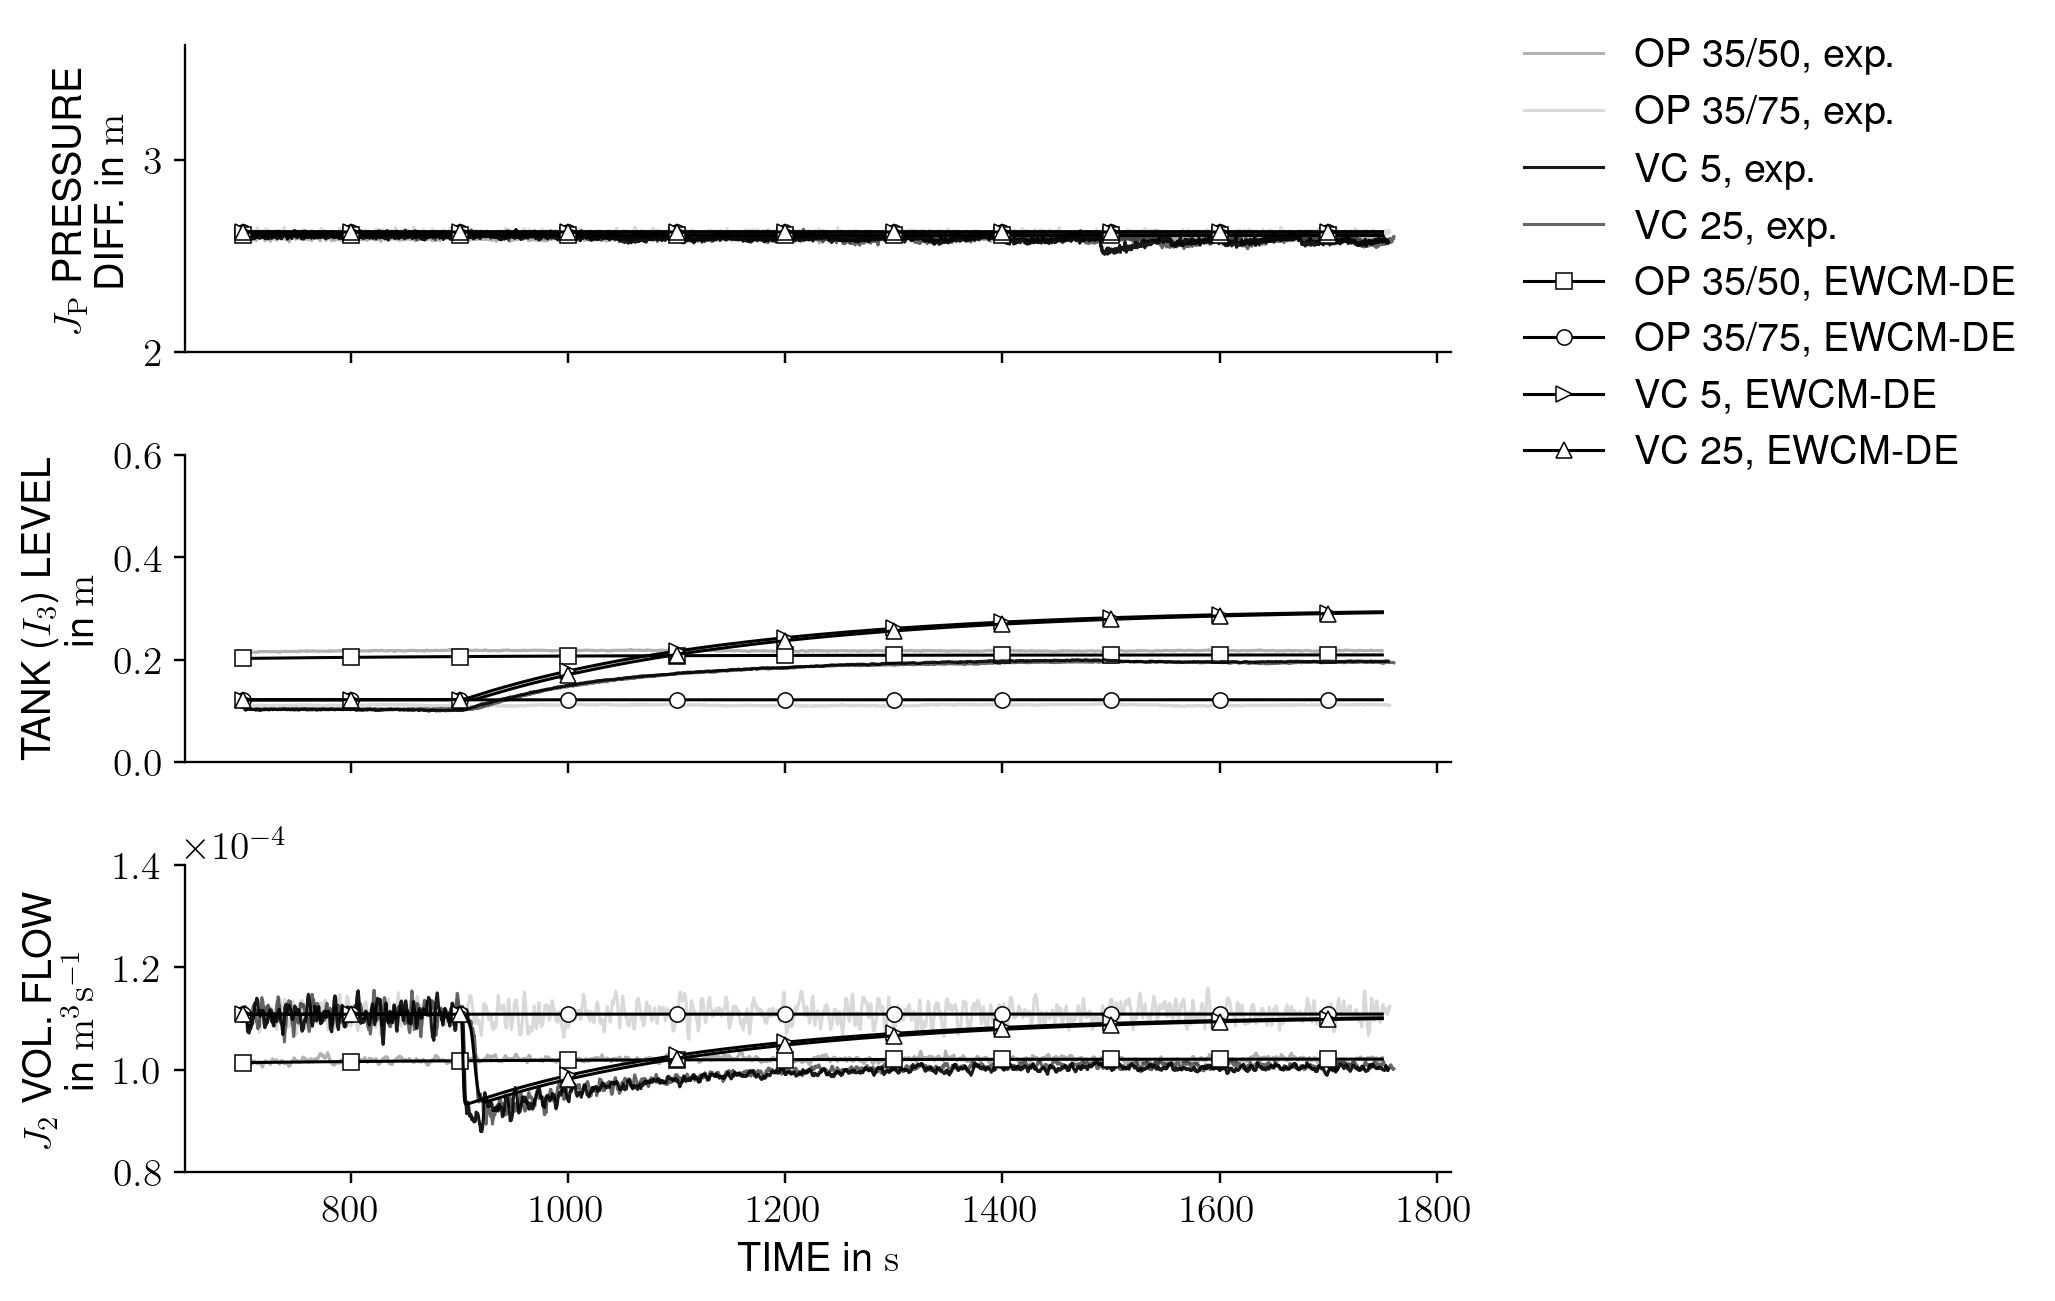

In [27]:
fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

plot_start_time = 700 * 100
plot_end_time = 1750 * 100

time_conv = len(exp_df_c_35_50["time"]) / (1800 * 100)

plot_start_time_exp = int(time_conv * plot_start_time)
plot_end_time_exp = int(time_conv * plot_end_time)

alpha = 0.3
linewidth = 1
markevery = 10000

marker_style = dict(
    markerfacecolor="w", markeredgecolor="k", markeredgewidth=0.5, markersize=5
)

## $J_\mathrm{P}$ PRESSURE
axs[0].plot(
    exp_df_c_35_75["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_75["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="c 35/75, exp",
    c="k",
    alpha=alpha / 2,
    linewidth=linewidth,
)


axs[0].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
    linewidth=linewidth,
)

axs[0].plot(
    exp_df_v_5s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_5s["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="valve closure 5s, exp",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
)

axs[0].plot(
    exp_df_v_25s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_25s["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="valve closure 25s, exp",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

axs[0].plot(
    sim_df_c_35_75["time"][plot_start_time:plot_end_time],
    sim_df_c_35_75["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_c_35_75["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="c 35/75, EWCM-DE",
    c="k",
    marker="o",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
axs[0].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_c_35_50["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[0].plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_v_5s["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="VC 5s, EWCM-DE",
    c="k",
    marker=">",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[0].plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_v_25s["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="valve closure 25s, EWCM-DE",
    c="k",
    marker="^",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)


## TANK ($I_\mathrm{3}$) LEVEL
(l1,) = axs[1].plot(
    exp_df_c_35_75["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_75["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="OP 35/75, exp.",
    c="k",
    alpha=alpha / 2,
    linewidth=linewidth,
)


(l2,) = axs[1].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="OP 35/50, exp.",
    c="k",
    alpha=alpha,
    linewidth=linewidth,
)

(l33,) = axs[1].plot(
    exp_df_v_5s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_5s["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="VC 5, exp.",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
    zorder=100,
)

(l3,) = axs[1].plot(
    exp_df_v_25s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_25s["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="VC 25, exp.",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

(l4,) = axs[1].plot(
    sim_df_c_35_75["time"][plot_start_time:plot_end_time],
    sim_df_c_35_75["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="OP 35/75, EWCM-DE",
    c="k",
    marker="o",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
(l5,) = axs[1].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="OP 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

(l66,) = axs[1].plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="VC 5, EWCM-DE",
    c="k",
    marker=">",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

(l6,) = axs[1].plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="VC 25, EWCM-DE",
    c="k",
    marker="^",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

## CONSUMER FLOW

axs[2].plot(
    exp_df_c_35_75["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_75["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="c 35/75, exp",
    c="k",
    alpha=alpha / 2,
    linewidth=linewidth,
)


axs[2].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
    linewidth=linewidth,
)

axs[2].plot(
    exp_df_v_5s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_5s["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="vc 5s, exp",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
)

axs[2].plot(
    exp_df_v_25s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_25s["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="vc 25s, exp",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

axs[2].plot(
    sim_df_c_35_75["time"][plot_start_time:plot_end_time],
    sim_df_c_35_75["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="c 35/75, EWCM-DE",
    c="k",
    marker="o",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
axs[2].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[2].plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="vc 5s, EWCM-DE",
    c="k",
    marker=">",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[2].plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="vc 25s, EWCM-DE",
    c="k",
    marker="^",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)


##  axs[0].plot(
##      exp_df_c_41_75["time"],
##      exp_df_c_41_75["test_rig.pump_1_pressure"] / (rho * g),
##      label="c 41/75, exp",
##      c="lightgrey",
##      alpha=alpha,
##  )
##  axs[0].plot(
##      sim_df_c_41_75["time"],
##      sim_df_c_41_75["h_I_pump_outlet"] - sim_df_c_41_75["h_I_pump_inlet"],
##      label="c 41/75, EWCM-DE",
##      c="k",
##  )

axs[0].set_ylim(2, 3.6)
axs[1].set_ylim(0, 0.6)
axs[2].set_ylim(0.00008, 0.00014)
# axs[0].set_xlabel("TIME in s")
axs[0].set_ylabel("$J_\mathrm{P}$ PRESSURE \n DIFF.  in $\mathrm{m}$")

# axs[1].set_xlabel("TIME in s")
axs[1].set_ylabel("TANK ($I_\mathrm{3}$) LEVEL \nin $\mathrm{m}$")

axs[2].set_xlabel("TIME in $\mathrm{s}$")
axs[2].set_ylabel("$J_2$ VOL. FLOW \nin $\mathrm{m}^3\mathrm{s}^{-1}$")

axs[2].ticklabel_format(scilimits=(1e-3, 1e5))

fig.legend(
    handles=[l2, l1, l33, l3, l5, l4, l66, l6],
    bbox_to_anchor=(0.98, 1),
    loc="upper left",
)
fig.tight_layout()

# fig.savefig("fig_vc.pdf", bbox_inches="tight")
fig.savefig("fig_vc.svg", bbox_inches="tight")
fig.savefig("fig_vc.png", bbox_inches="tight")

## Plot OP 35/50, pump speedup

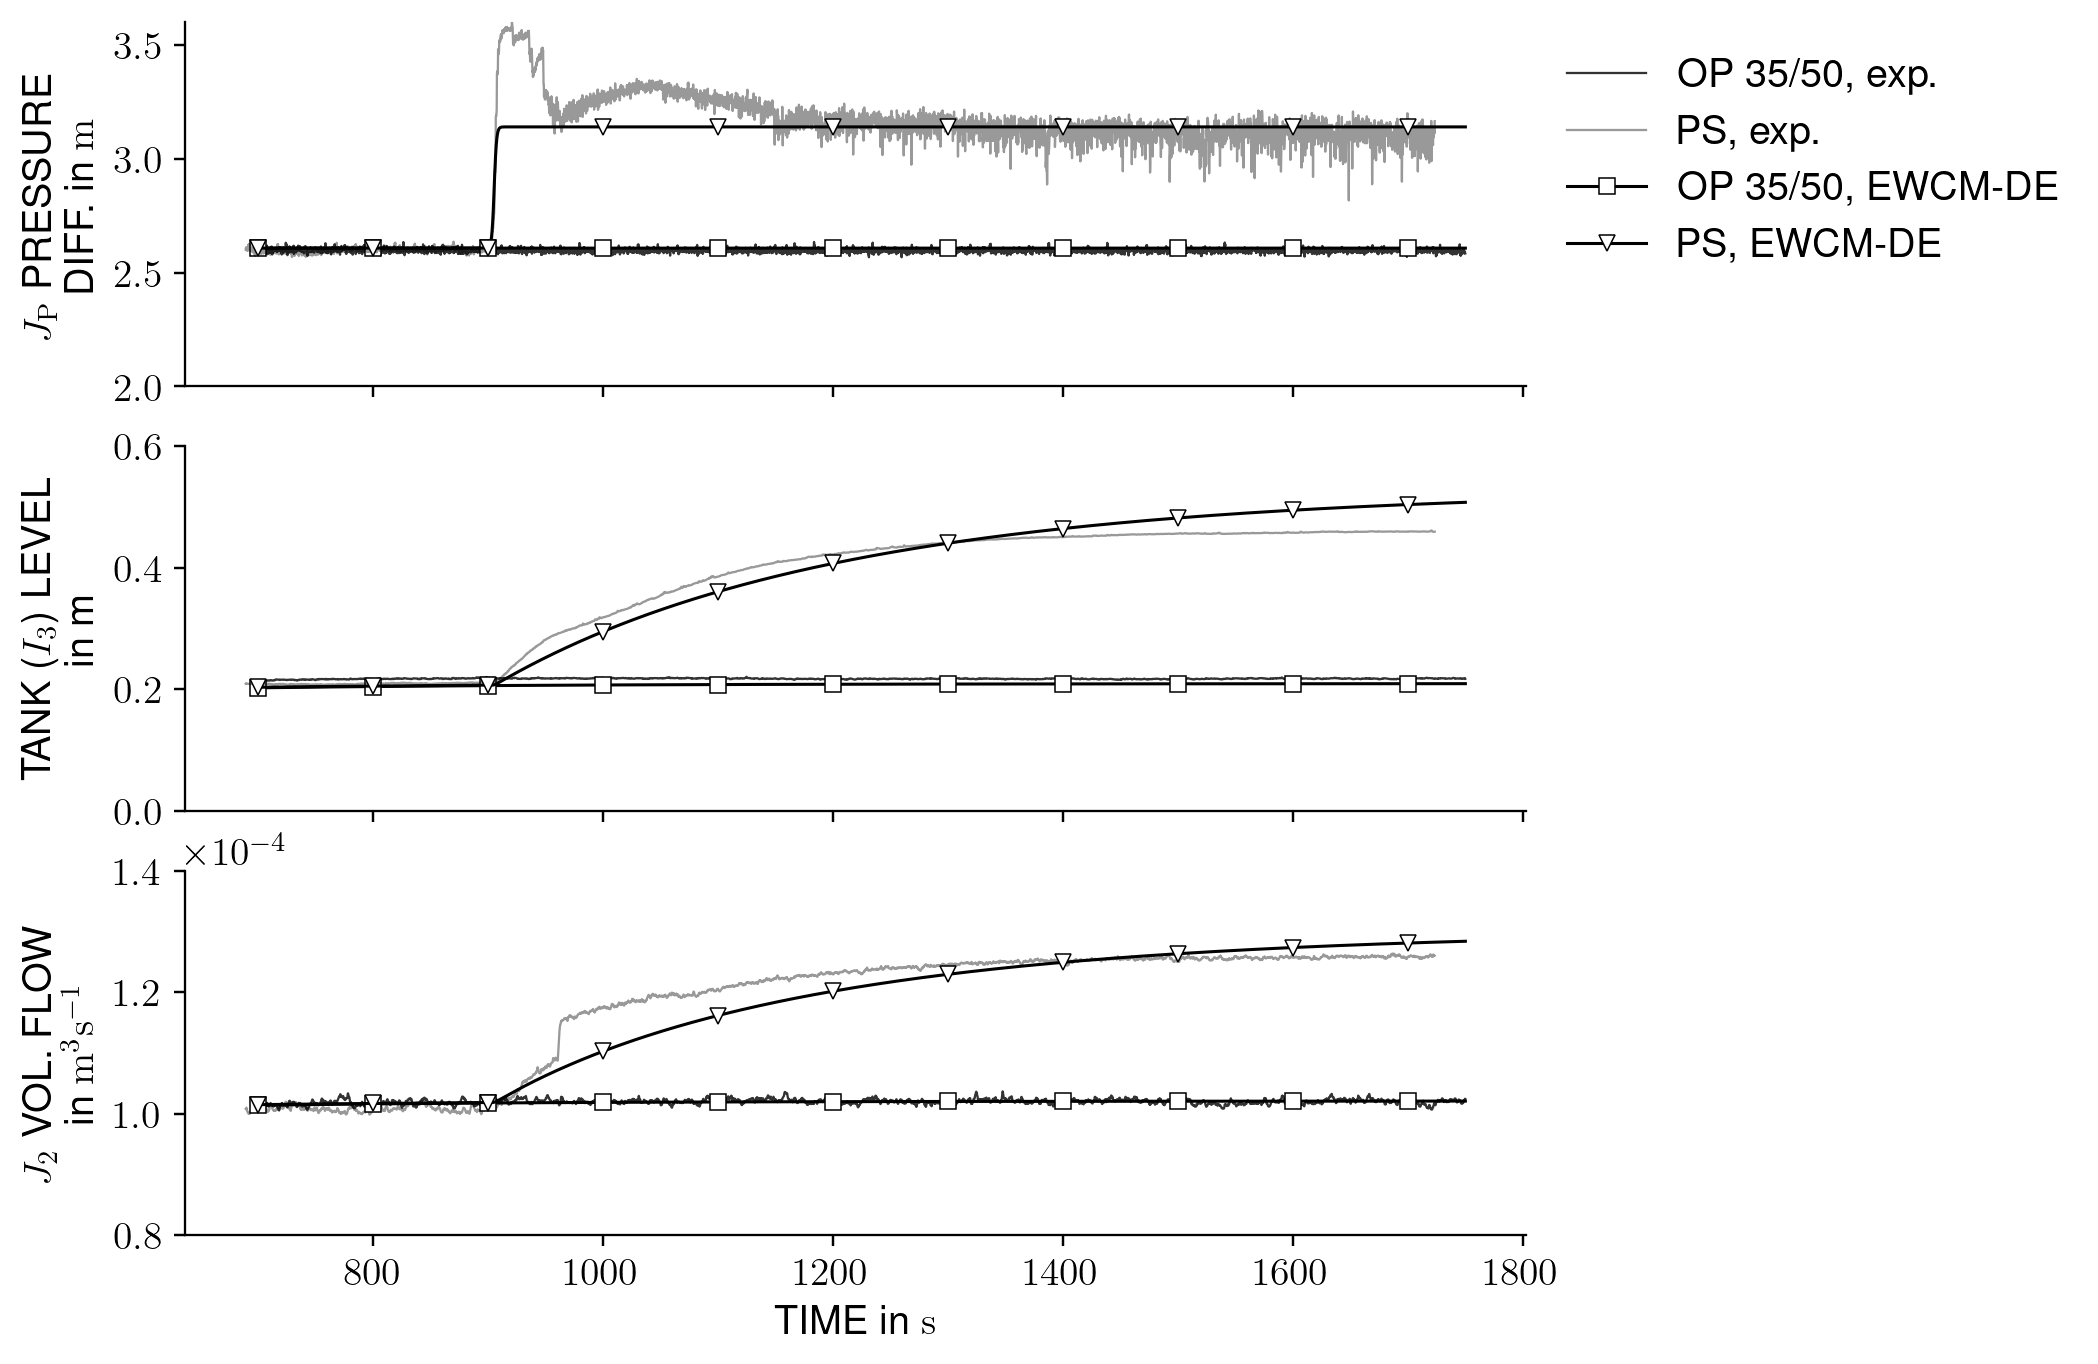

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

plot_start_time = 700 * 100
plot_end_time = 1750 * 100

time_conv = len(exp_df_c_35_50["time"]) / (1800 * 100)

plot_start_time_exp = int(time_conv * plot_start_time)
plot_end_time_exp = int(time_conv * plot_end_time)

alpha = 0.8

## $J_\mathrm{P}$ PRESSURE
(l1,) = axs[0].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label=r"OP 35/50, exp.",
    c="k",
    alpha=alpha,
)
(l2,) = axs[0].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_c_35_50["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label=r"OP 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
## axs[0].plot(
##     exp_df_c_41_75["time"],
##     exp_df_c_41_75["test_rig.pump_1_pressure"] / (rho * g),
##     label="c 41/75, exp",
##     c="lightgrey",
##     alpha=alpha,
## )


## axs[0].plot(
##     sim_df_c_41_75["time"],
##     sim_df_c_41_75["h_I_pump_outlet"] - sim_df_c_41_75["h_I_pump_inlet"],
##     label="c 41/75, EWCM-DE",
##     c="k",
## )#


(l3,) = axs[0].plot(
    exp_df_p_35_41["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_p_35_41["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label=r"PS, exp.",
    c="k",
    alpha=alpha / 2,
)

(l4,) = axs[0].plot(
    sim_df_p_35_41["time"][plot_start_time:plot_end_time],
    sim_df_p_35_41["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_p_35_41["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label=r"PS, EWCM-DE",
    c="k",
    marker="v",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
axs[0].set_ylim(2.56, 2.66)

## TANK ($I_\mathrm{3}$) LEVEL
axs[1].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
)


## axs[1].plot(
##     exp_df_c_41_75["time"],
##     exp_df_c_41_75["test_rig.tank_1_pressure"] / (rho * g),
##     label="c 41/75, exp",
##     c="lightgrey",
##     alpha=alpha,
## )

## axs[1].plot(
##     sim_df_c_41_75["time"],
##     sim_df_c_41_75["h_I_tank_outlet"] - 1.2,
##     label="c 41/75, EWCM-DE",
##     c="k",
## )
axs[1].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[1].plot(
    exp_df_p_35_41["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_p_35_41["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="PS, exp",
    c="k",
    alpha=alpha / 2,
)

axs[1].plot(
    sim_df_p_35_41["time"][plot_start_time:plot_end_time],
    sim_df_p_35_41["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="pump speedup, EWCM-DE",
    c="k",
    marker="v",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

## CONSUMER FLOW

## axs[2].plot(
##     exp_df_c_41_75["time"],
##     exp_df_c_41_75["test_rig.consumer_1_volume_flow"],
##     label="c 41/75, exp",
##     c="lightgrey",
##     alpha=alpha,
## )


axs[2].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
)

axs[2].plot(
    exp_df_p_35_41["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_p_35_41["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="PS, exp",
    c="k",
    alpha=alpha / 2,
)


axs[2].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

# # axs[2].plot(
# #     sim_df_c_41_75["time"],
# #     sim_df_c_41_75["q_p_tank_outlet_pipe"],
# #     label="c 41/75, EWCM-DE",
# #     c="k",
# # )

axs[2].plot(
    sim_df_p_35_41["time"][plot_start_time:plot_end_time],
    sim_df_p_35_41["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="pump speedup, EWCM-DE",
    c="k",
    marker="v",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

## axs[0].set_ylim(2, 3.8)
## axs[1].set_ylim(0.0, 0.6)
## axs[2].set_ylim(0.00007, 0.00015)
axs[0].set_ylim(2, 3.6)
axs[1].set_ylim(0, 0.6)
axs[2].set_ylim(0.00008, 0.00014)

# axs[0].set_xlabel("TIME in s")
axs[0].set_ylabel("$J_\mathrm{P}$ PRESSURE \n DIFF. in $\mathrm{m}$")

# axs[1].set_xlabel("TIME in s")
axs[1].set_ylabel("TANK ($I_\mathrm{3}$) LEVEL \nin m")

axs[2].set_xlabel("TIME in $\mathrm{s}$")
axs[2].set_ylabel("$J_2$ VOL. FLOW \nin $\mathrm{m}^3\mathrm{s}^{-1}$")

axs[2].ticklabel_format(scilimits=(1e-3, 1e5))
fig.legend(handles=[l1, l3, l2, l4], bbox_to_anchor=(0.98, 1), loc="upper left")
fig.tight_layout(pad=0)

# fig.savefig("fig_ps.pdf", bbox_inches="tight")
fig.savefig("fig_ps.svg", bbox_inches="tight")
fig.savefig("fig_ps.png", bbox_inches="tight")

## Plot valve opening

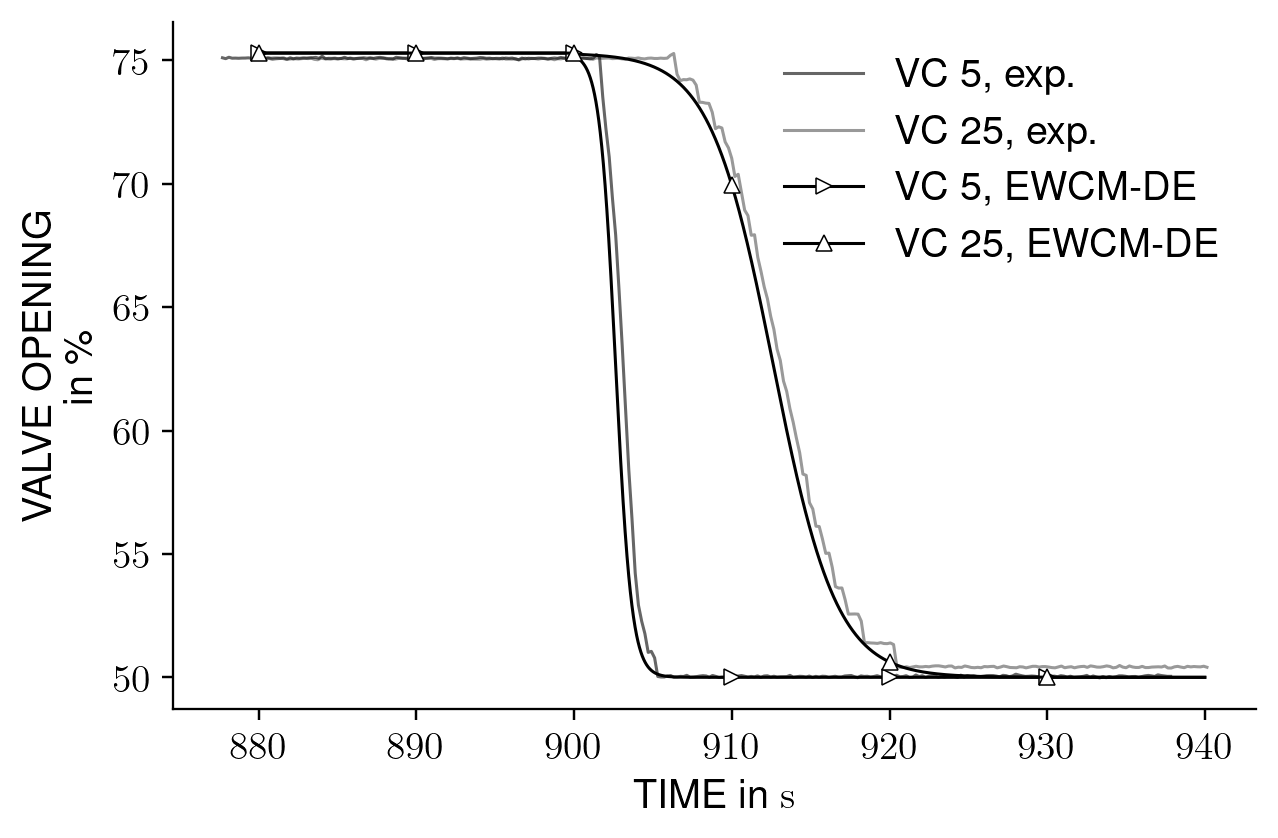

In [ ]:
fig, axs = plt.subplots(1, figsize=(6, 4))


plot_start_time = 880 * 100
plot_end_time = 940 * 100

time_conv = len(exp_df_c_35_50["time"]) / (1800 * 100)

plot_start_time_exp = int(time_conv * plot_start_time)
plot_end_time_exp = int(time_conv * plot_end_time)

alpha = 0.2
linewidth = 1
markevery = 10000

marker_style = dict(
    markerfacecolor="w", markeredgecolor="k", markeredgewidth=0.5, markersize=5
)

axs.plot(
    exp_df_v_5s["time"][plot_start_time_exp - 25 : plot_end_time_exp - 25],
    exp_df_v_5s["test_rig.consumer_1_valve_opening"][
        plot_start_time_exp - 25 : plot_end_time_exp - 25
    ],
    label="VC 5, exp.",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
)


axs.plot(
    exp_df_v_25s["time"][plot_start_time_exp - 25 : plot_end_time_exp - 25],
    exp_df_v_25s["test_rig.consumer_1_valve_opening"][
        plot_start_time_exp - 25 : plot_end_time_exp - 25
    ],
    label="VC 25, exp.",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

axs.plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["z_v_consumer_valve"][plot_start_time:plot_end_time] * 100,
    label="VC 5, EWCM-DE",
    c="k",
    marker=">",
    markevery=1000,
    linewidth=linewidth,
    **marker_style,
)

axs.plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["z_v_consumer_valve"][plot_start_time:plot_end_time] * 100,
    label="VC 25, EWCM-DE",
    c="k",
    marker="^",
    markevery=1000,
    linewidth=linewidth,
    **marker_style,
)

# axs[1].plot(
#     exp_df_p_35_41["time"][plot_start_time_exp + 50 : plot_end_time_exp + 50],
#     exp_df_p_35_41["pump_1.output"][plot_start_time_exp + 50 : plot_end_time_exp + 50],
#     label="PS, exp.",
#     c="k",
#     alpha=alpha * 2,
#     linewidth=linewidth,
# )

# axs[1].plot(
#     sim_df_p_35_41["time"][plot_start_time:plot_end_time],
#     sim_df_p_35_41["z_p_pump"][plot_start_time:plot_end_time],
#     label="PS, EWCM-DE",
#     c="k",
#     marker="v",
#     markevery=1000,
#     linewidth=linewidth,
#     **marker_style,
# )


axs.set_xlabel("TIME in $\mathrm{s}$")
axs.set_ylabel("VALVE OPENING \nin \%")

# axs[1].set_xlabel("TIME in $\mathrm{s}$")
# axs[1].set_ylabel("PUMP SPEED \nin $\mathrm{s}^{-1}$")

axs.legend()
# axs[1].legend()

fig.tight_layout()
# fig.savefig("fig_dynamic_elements.pdf")
fig.savefig("fig_dynamic_elements.svg")
fig.savefig("fig_dynamic_elements.png")